In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Hypertension Stage Prediction (ML + Recommendations)

## Objective
Predict and classify hypertension stages (Normal, Elevated, Stage1, Stage2, Severe) using clinical and lifestyle features from the Cardiovascular Disease dataset.

## Output
- Hypertension stage prediction
- Risk score (confidence)
## - Personalized recommendations

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cardio_train.csv to cardio_train.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

What it does: Imports all libraries for:
	•	data handling (pandas, numpy)
	•	graphs (matplotlib, seaborn)
	•	ML pipeline + models + evaluation (sklearn)
	•	saving model (joblib)

In [4]:
df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
print("Shape:", df.shape)
df.info()


Shape: (70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
df["age_years"] = (df["age"] / 365.25).round(1)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

df[["age", "age_years", "height", "weight", "bmi"]].head()


,age,age_years,height,weight,bmi
0,18393,50.4,168,62.0,21.967120
1,20228,55.4,156,85.0,34.927679
2,18857,51.6,165,64.0,23.507805
3,17623,48.2,169,82.0,28.710479
4,17474,47.8,156,56.0,23.011177


	•	converts age from days → years
	•	creates BMI (super useful clinical feature)

In [7]:
def bp_stage(sys_bp, dia_bp):
    if sys_bp > 180 or dia_bp > 120:
        return "Severe"
    elif sys_bp >= 140 or dia_bp >= 90:
        return "Stage2"
    elif (130 <= sys_bp <= 139) or (80 <= dia_bp <= 89):
        return "Stage1"
    elif (120 <= sys_bp <= 129) and dia_bp < 80:
        return "Elevated"
    else:
        return "Normal"

df["hypertension_stage"] = df.apply(lambda r: bp_stage(r["ap_hi"], r["ap_lo"]), axis=1)

df[["ap_hi","ap_lo","hypertension_stage"]].head()

,ap_hi,ap_lo,hypertension_stage
0,110,80,Stage1
1,140,90,Stage2
2,130,70,Stage1
3,150,100,Stage2
4,100,60,Normal


Uses systolic (ap_hi) and diastolic (ap_lo) to assign each row a stage label.

In [8]:
df = df[df["ap_hi"].between(70, 260)]
df = df[df["ap_lo"].between(40, 160)]
df = df[df["bmi"].between(10, 60)]

print("After cleaning:", df.shape)

After cleaning: (68696, 16)


In [9]:
df["hypertension_stage"].value_counts()

,count
hypertension_stage,
Stage1,32432
Stage2,23271
Normal,9548
Elevated,3106
Severe,339


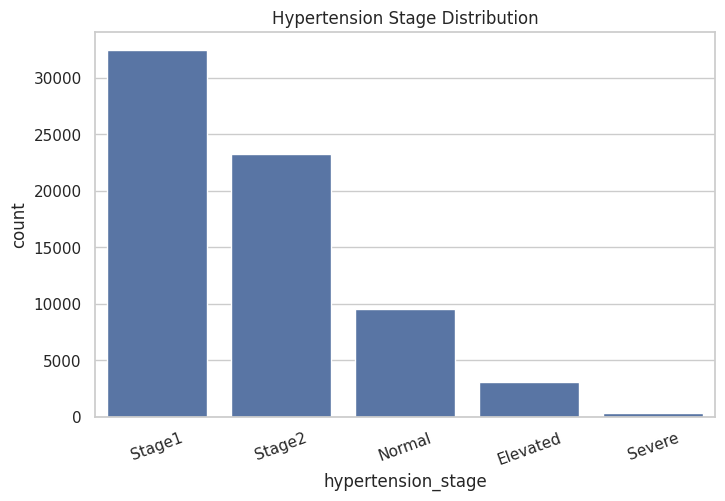

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="hypertension_stage", order=df["hypertension_stage"].value_counts().index)
plt.title("Hypertension Stage Distribution")
plt.xticks(rotation=20)
plt.show()

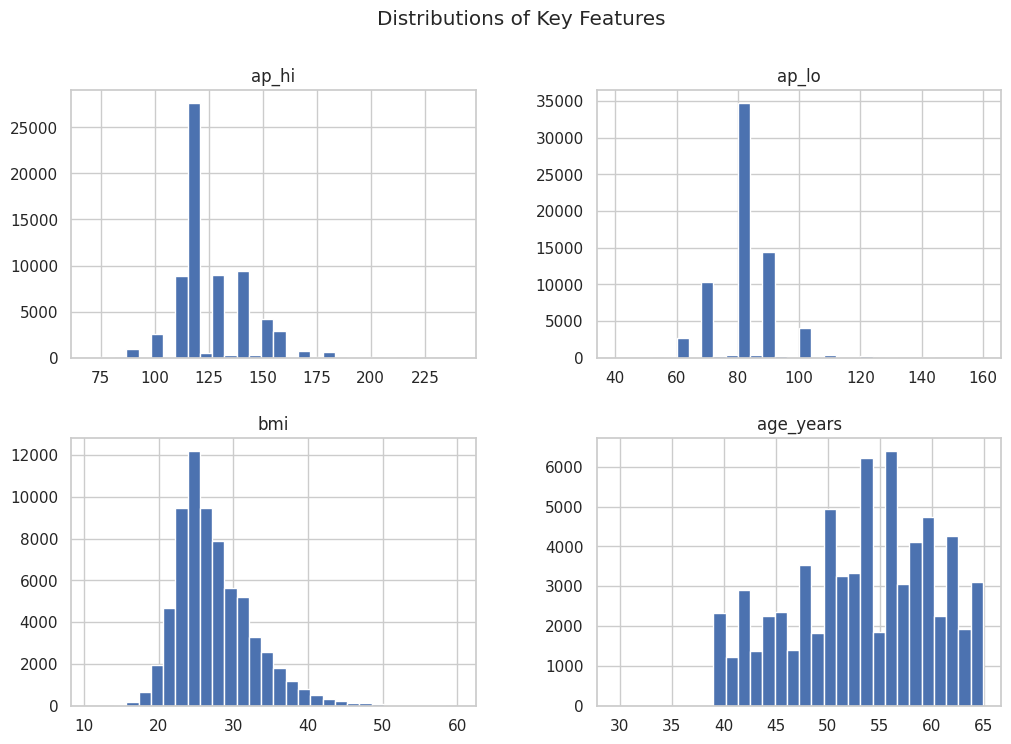

In [11]:
features = ["ap_hi", "ap_lo", "bmi", "age_years"]
df[features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distributions of Key Features")
plt.show()

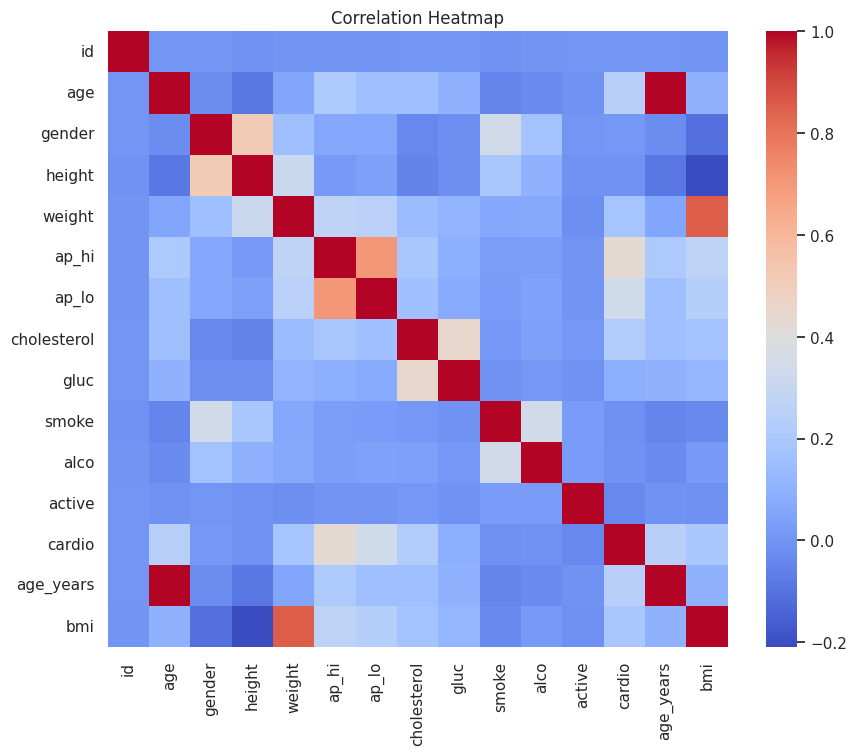

In [12]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

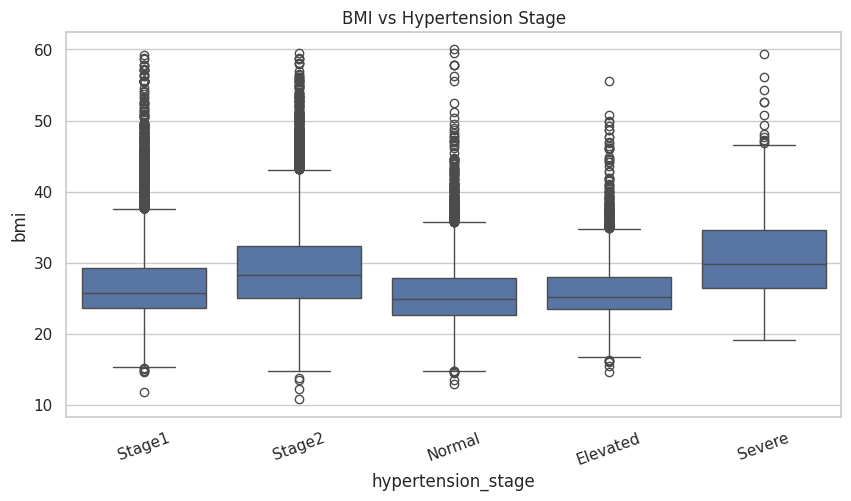

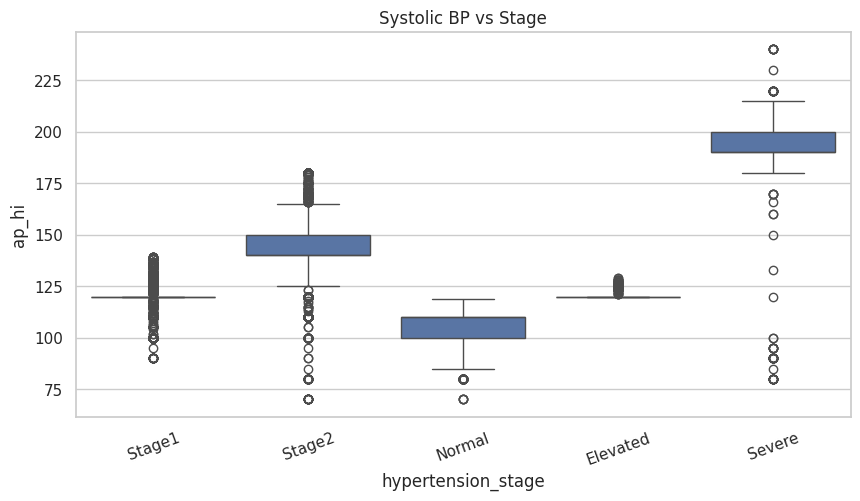

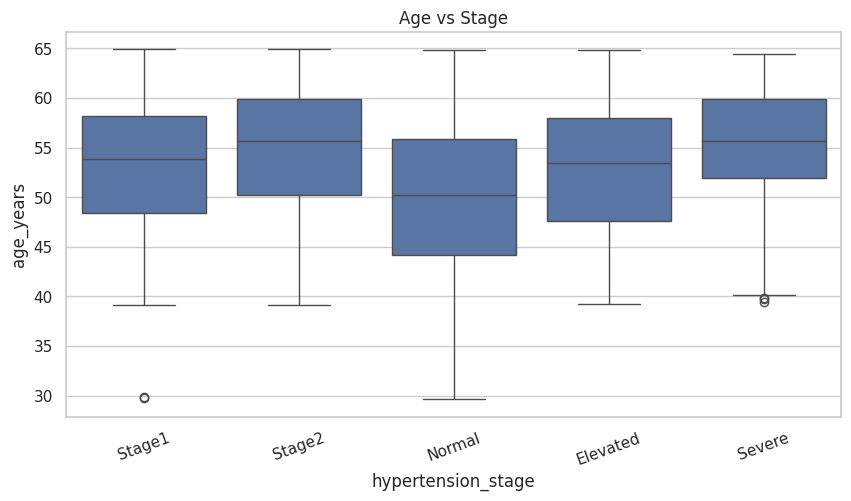

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="hypertension_stage", y="bmi")
plt.title("BMI vs Hypertension Stage")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="hypertension_stage", y="ap_hi")
plt.title("Systolic BP vs Stage")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="hypertension_stage", y="age_years")
plt.title("Age vs Stage")
plt.xticks(rotation=20)
plt.show()

In [21]:
target = "hypertension_stage"

# Drop target AND BP readings from features to avoid leakage
X = df.drop(columns=[target, "ap_hi", "ap_lo"])
y = df[target]

# Drop ID + raw age (we use age_years)
X = X.drop(columns=["id", "age"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (68696, 11)
y shape: (68696,)


,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,168,62.0,1,1,0,0,1,0,50.4,21.967120
1,1,156,85.0,3,1,0,0,1,1,55.4,34.927679
2,1,165,64.0,3,1,0,0,0,1,51.6,23.507805
3,2,169,82.0,1,1,0,0,1,1,48.2,28.710479
4,1,156,56.0,1,1,0,0,0,0,47.8,23.011177


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (54956, 11)
Test size: (13740, 11)


In [23]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(exclude=["int64","float64"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [24]:
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000))
])

param_grid = [
    {"model": [LogisticRegression(max_iter=3000)], "model__C": [0.5, 1, 2]},
    {"model": [DecisionTreeClassifier(random_state=42)], "model__max_depth": [4, 6, 10, None]},
    {"model": [RandomForestClassifier(random_state=42, n_jobs=-1)],
     "model__n_estimators": [200],
     "model__max_depth": [10, 16, None]},
    {"model": [GradientBoostingClassifier(random_state=42)],
     "model__n_estimators": [100, 200],
     "model__learning_rate": [0.05, 0.1]},
]

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,                 # faster than 5
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.05, 'model__n_estimators': 200}


In [25]:
preds = best_model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

    Elevated       0.00      0.00      0.00       621
      Normal       0.53      0.14      0.22      1910
      Severe       0.00      0.00      0.00        68
      Stage1       0.58      0.70      0.63      6487
      Stage2       0.58      0.67      0.62      4654

    accuracy                           0.58     13740
   macro avg       0.34      0.30      0.29     13740
weighted avg       0.54      0.58      0.54     13740



In [26]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "overweight"
    else:
        return "obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

df["bmi_category"].value_counts()

,count
bmi_category,
normal,25452
overweight,24663
obese,17943
underweight,638


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000))
])

param_grid = [
    # Logistic Regression (balanced)
    {
        "model": [LogisticRegression(max_iter=3000, class_weight="balanced")],
        "model__C": [0.5, 1, 2]
    },
    # Random Forest (balanced)
    {
        "model": [RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")],
        "model__n_estimators": [200, 400],
        "model__max_depth": [10, 16, None]
    }
]

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'model': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42), 'model__max_depth': 16, 'model__n_estimators': 200}


In [28]:
preds = best_model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

    Elevated       0.07      0.05      0.06       621
      Normal       0.35      0.40      0.37      1910
      Severe       0.00      0.00      0.00        68
      Stage1       0.60      0.46      0.52      6487
      Stage2       0.55      0.72      0.63      4654

    accuracy                           0.52     13740
   macro avg       0.31      0.33      0.32     13740
weighted avg       0.52      0.52      0.51     13740



In [29]:
import joblib

joblib.dump(best_model, "hypertension_model.joblib")
print("Model saved successfully")

Model saved successfully


In [30]:
from google.colab import files
files.download("hypertension_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
def generate_recommendations(stage, patient):

    recs = []

    if stage == "Normal":
        recs.append("Maintain a balanced diet and regular exercise.")
        recs.append("Monitor blood pressure periodically.")

    elif stage == "Elevated":
        recs.append("Reduce sodium intake.")
        recs.append("Increase physical activity.")
        recs.append("Maintain healthy body weight.")

    elif stage == "Stage1":
        recs.append("Adopt DASH diet (low salt, more fruits & vegetables).")
        recs.append("Exercise at least 150 minutes per week.")
        recs.append("Monitor blood pressure regularly.")

    elif stage == "Stage2":
        recs.append("Consult a healthcare professional.")
        recs.append("Strictly control salt intake.")
        recs.append("Increase physical activity and reduce stress.")

    elif stage == "Severe":
        recs.append("Seek immediate medical attention.")
        recs.append("Avoid alcohol and smoking.")
        recs.append("Follow medical treatment strictly.")

    if patient.get("smoke",0) == 1:
        recs.append("Quit smoking to reduce cardiovascular risk.")

    if patient.get("active",1) == 0:
        recs.append("Increase physical activity levels.")

    return recs

In [32]:
stage = "Stage2"

patient = {
    "smoke":1,
    "active":0
}

generate_recommendations(stage, patient)

['Consult a healthcare professional.',
 'Strictly control salt intake.',
 'Increase physical activity and reduce stress.',
 'Quit smoking to reduce cardiovascular risk.',
 'Increase physical activity levels.']